# FUNCIONA

/home/cgonzalez/Object_Recognition/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Ejecutando en: cuda
Imágenes de validación cargadas: 40


/home/cgonzalez/Object_Recognition/src/utils/data_augmentations.py:27: UserWarning: Argument(s) 'max_holes, max_height, max_width' are not valid for transform CoarseDropout
  A.CoarseDropout(


Modelo EfficientDet-D1 cargado (Cabezas de predicción aleatorias para 3 clases).

>>> Ejecutando inferencia sobre un batch de validación...


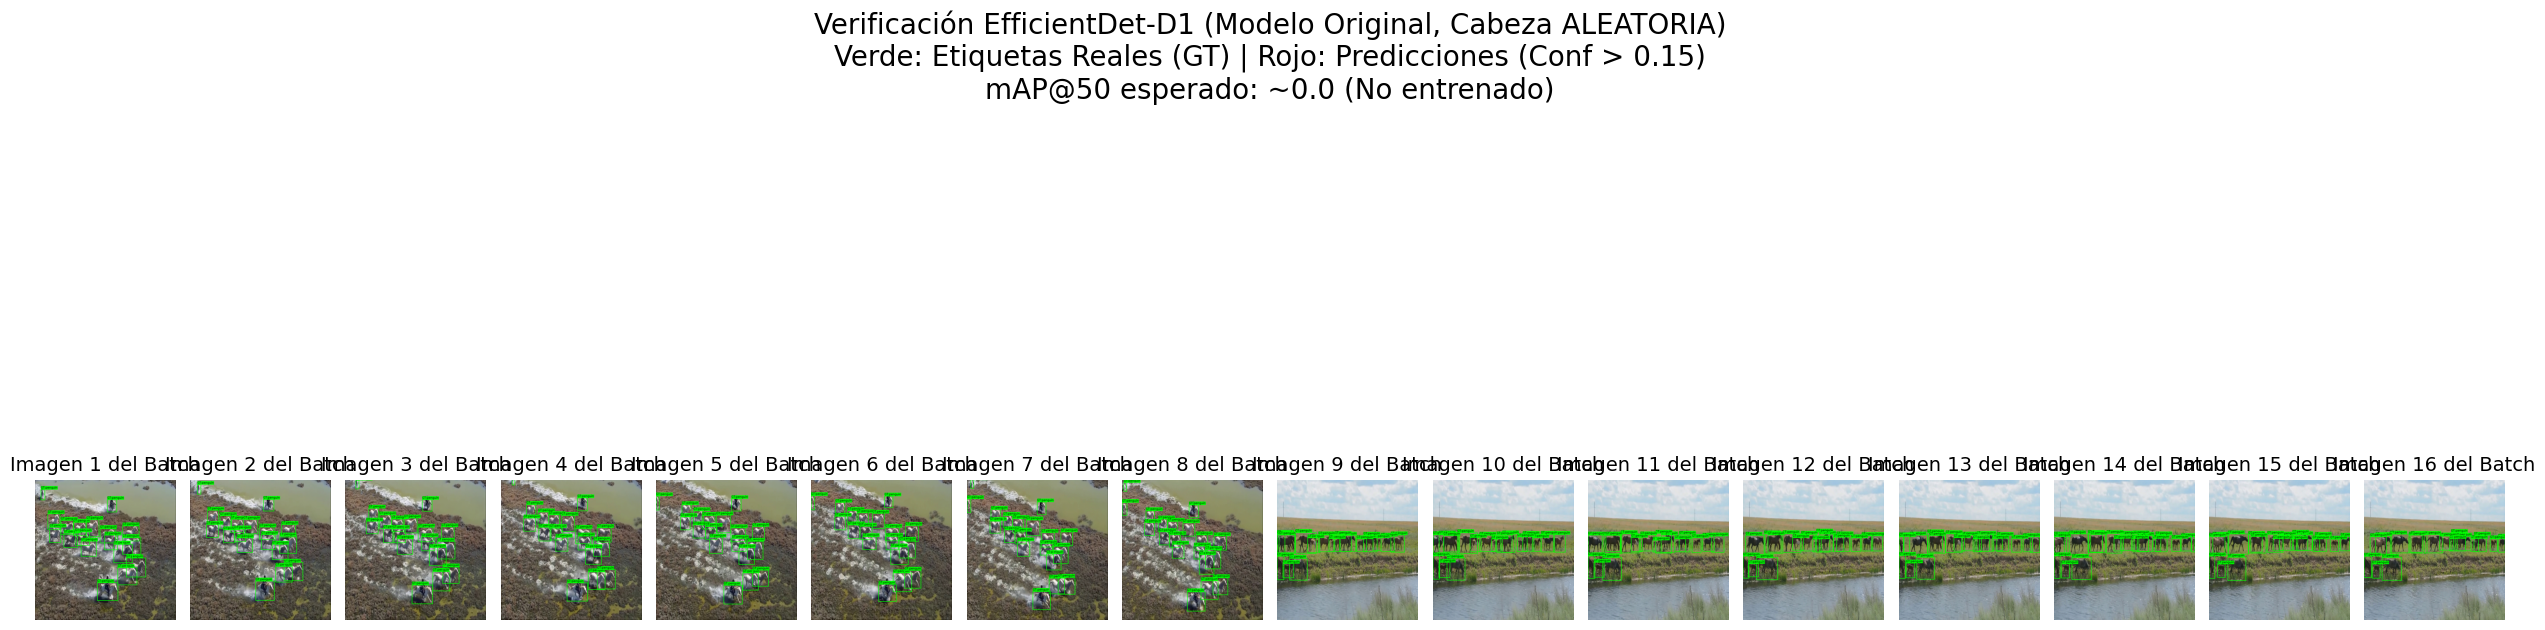


>>> Verificación completada.
Verás cajas verdes (etiquetas correctas) y cajas rojas aleatorias (ruido del modelo no entrenado).
El flujo de datos está validado. Siguiente paso: Entrenamiento Fase 1 (Warm-up).


In [ ]:
import torch
from pathlib import Path
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import numpy as np
import cv2
from typing import List, Dict

# Importaciones de TU proyecto
from dataset.efficientdet_dataset import EfficientDetDataset
from models.efficientdet import EfficientDet
from utils.data_augmentations import get_transforms

# ==========================================
# 1. CONFIGURACIÓN Y RUTAS
# ==========================================
PROJECT_ROOT = Path().resolve().parent
# Usamos el split de validación del Set 1 (Balanceado) para inferencia
VAL_TXT = PROJECT_ROOT / "dataset/processed/experiments/set1_balanced_subsampled/fold_1_val.txt"
TRAIN_TXT = PROJECT_ROOT / "dataset/processed/experiments/set1_balanced_subsampled/fold_1_train.txt"
IMG_SIZE = 720 # Unificado para Modelo y Dataset
BATCH_SIZE = 16 # Para visualizar un batch completo en subplot

# Mapeo de IDs (debe coincidir con la lógica aplicada en paths.yaml/03_split)
# Asumiendo: 0: horse, 1: penguin, 2: pig tras la conversión YOLO
class_names_map = {0: 'horse', 1: 'penguin', 2: 'pig'}

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Ejecutando en: {device}")

# ==========================================
# 2. DATASET Y DATALOADER (Modo Validación)
# ==========================================
# OJO: Asegúrate de haber cambiado target_size=640 en utils/data_augmentations.py
# o pásalo explícitamente aquí si has actualizado el script.
train_ds = EfficientDetDataset(
    split_txt=TRAIN_TXT,
    img_size=IMG_SIZE,
    transforms=get_transforms('train', target_size=IMG_SIZE)
)
val_ds = EfficientDetDataset(
    split_txt=VAL_TXT,
    img_size=IMG_SIZE,
    transforms=get_transforms('val', target_size=IMG_SIZE)
)

def collate_fn(batch):
    return tuple(zip(*batch))

val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False, collate_fn=collate_fn)
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, collate_fn=collate_fn)

print(f"Imágenes de validación cargadas: {len(val_ds)}")

# ==========================================
# 3. CARGA DEL MODELO ORIGINAL (Untrained Head)
# ==========================================
# Cargamos en modo inferencia (is_training=False) para que devuelva detecciones, no pérdidas.
# pretrained=True carga backbone COCO, cabeza aleatoria para 3 clases.
model = EfficientDet(num_classes=3, img_size=IMG_SIZE, architecture= 'tf_efficientdet_d3',is_training=False, pretrained=True)
model.to(device)
model.eval() # Modo evaluación crítico (quita Dropout, BN, etc.)

print("Modelo EfficientDet-D1 cargado (Cabezas de predicción aleatorias para 3 clases).")

# ==========================================
# 4. UTILIDADES DE VISUALIZACIÓN
# ==========================================
def denormalize_image(img_tensor: torch.Tensor) -> np.ndarray:
    """Invierte la normalización de Albumentations (ImageNet) para visualizar."""
    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])
    
    img_np = img_tensor.permute(1, 2, 0).cpu().numpy() # [C,H,W] -> [H,W,C]
    img_np = (img_np * std) + mean # Desnormalizar
    img_np = np.clip(img_np, 0, 1) # Asegurar rango [0,1]
    img_np = (img_np * 255).astype(np.uint8) # Rango [0,255] uint8
    return img_np

def draw_boxes_on_image(image_rgb: np.ndarray, target: Dict, predictions: torch.Tensor, 
                         class_map: Dict, conf_thresh: float = 0.2) -> np.ndarray:
    """Dibuja Ground Truth (Verde) y Predicciones (Rojo) sobre la imagen."""
    
    # Clonamos para no modificar la original
    canvas = cv2.cvtColor(image_rgb, cv2.COLOR_RGB2BGR)
    
    # Colores BGR
    GT_COLOR = (0, 255, 0)   # Verde para Etiquetas Reales
    PRED_COLOR = (0, 0, 255) # Rojo para Predicciones del Modelo
    FONT = cv2.FONT_HERSHEY_SIMPLEX

    # A. Dibujar GROUND TRUTH (GT)
    # Tu dataset devuelve formato [y_min, x_min, y_max, x_max] absolutos
    gt_boxes = target['bbox'].cpu().numpy()
    gt_labels = target['cls'].cpu().numpy()
    
    for box, label_id in zip(gt_boxes, gt_labels):
        ymin, xmin, ymax, xmax = map(int, box)
        class_name = class_map.get(int(label_id), f"ID:{label_id}")
        
        # Rectángulo GT
        cv2.rectangle(canvas, (xmin, ymin), (xmax, ymax), GT_COLOR, 2)
        
        # Etiqueta texto GT
        label_txt = f"GT:{class_name}"
        (w, h), _ = cv2.getTextSize(label_txt, FONT, 0.5, 1)
        cv2.rectangle(canvas, (xmin, ymin - h - 5), (xmin + w, ymin), GT_COLOR, -1) # Fondo texto
        cv2.putText(canvas, label_txt, (xmin, ymin - 5), FONT, 0.5, (0,0,0), 1, cv2.LINE_AA)

    # B. Dibujar PREDICCIONES
    # effdet DetBenchPredict devuelve: [batch_id, [x_min, y_min, x_max, y_max, score, class_id]] absolutos
    # OJO: Formato cajas de predicción es XYXY, diferente al YXYX de tu GT
    if predictions is not None and len(predictions) > 0:
        # Filtramos por umbral de confianza
        valid_preds = predictions[predictions[:, 4] > conf_thresh]
        
        for pred in valid_preds:
            xmin, ymin, xmax, ymax, score, label_id = pred
            xmin, ymin, xmax, ymax = map(int, [xmin, ymin, xmax, ymax])
            
            # Como la cabeza es aleatoria, label_id podría ser inválido
            class_name = class_map.get(int(label_id), f"ID:{label_id}")

            # Rectángulo Predicción
            cv2.rectangle(canvas, (xmin, ymin), (xmax, ymax), PRED_COLOR, 2)
            
            # Etiqueta texto Predicción + Score
            pred_txt = f"PR:{class_name} {score:.2f}"
            (w, h), _ = cv2.getTextSize(pred_txt, FONT, 0.5, 1)
            cv2.rectangle(canvas, (xmin, ymax), (xmin + w, ymax + h + 5), PRED_COLOR, -1) # Fondo texto abajo
            cv2.putText(canvas, pred_txt, (xmin, ymax + h + 2), FONT, 0.5, (255,255,255), 1, cv2.LINE_AA)

    return cv2.cvtColor(canvas, cv2.COLOR_BGR2RGB) # Volver a RGB para Matplotlib

# ==========================================
# 5. INFERENCIA Y VISUALIZACIÓN DEL BATCH
# ==========================================
print("\n>>> Ejecutando inferencia sobre un batch de validación...")

# Tomamos el primer batch del val_loader
images, targets = next(iter(val_loader))

# Preparar imágenes para el modelo [BATCH, 3, 640, 640] en device
images_stack = torch.stack(images).to(device).float()

with torch.no_grad():
    # detections es una lista de longitud BATCH, cada elemento tensor de predicciones
    detections = model(images_stack)

# Umbral de confianza bajo para ver "algo" aunque sea ruido
CONF_THRESH_VIS = 0.15 

# Configurar Subplots
fig, axes = plt.subplots(1, BATCH_SIZE, figsize=(25, 10), dpi=100)
fig.suptitle(f"Verificación EfficientDet-D1 (Modelo Original, Cabeza ALEATORIA)\n"
             f"Verde: Etiquetas Reales (GT) | Rojo: Predicciones (Conf > {CONF_THRESH_VIS})\n"
             f"mAP@50 esperado: ~0.0 (No entrenado)", fontsize=20, y=0.95)

for i in range(BATCH_SIZE):
    # Procesa imagen i del batch
    img_rgb = denormalize_image(images[i])
    target = targets[i]
    
    # detecciones[i] podría ser None o estar vacío si no hay nada por encima de NMS interno
    preds_i = detections[i] if (detections is not None and len(detections) > i) else None
    
    # Dibujar GT y Preds
    annotated_img = draw_boxes_on_image(img_rgb, target, preds_i, class_names_map, conf_thresh=CONF_THRESH_VIS)
    
    axes[i].imshow(annotated_img)
    axes[i].set_title(f"Imagen {i+1} del Batch", fontsize=14)
    axes[i].axis('off')

plt.tight_layout(rect=[0, 0, 1, 0.93])
plt.show()

print("\n>>> Verificación completada.")
print("Verás cajas verdes (etiquetas correctas) y cajas rojas aleatorias (ruido del modelo no entrenado).")
print("El flujo de datos está validado. Siguiente paso: Entrenamiento Fase 1 (Warm-up).")

In [2]:
from torchmetrics.detection.mean_ap import MeanAveragePrecision
from pprint import pprint
from tqdm import tqdm

# ==========================================
# 1. FUNCIÓN DE VALIDACIÓN
# ==========================================
def validate(model, dataloader, device):
    model.eval() # Modo evaluación
    # Inicializamos la métrica de TorchMetrics (formato COCO)
    metric = MeanAveragePrecision(box_format='xyxy', class_metrics=True)
    
    val_pbar = tqdm(dataloader, desc="Validating", leave=False)
    
    with torch.no_grad():
        for images, targets in val_pbar:
            images_stack = torch.stack(images).to(device).float()
            
            # 1. Inferencia (DetBenchPredict ya aplica NMS internamente)
            # Retorna: [batch_id, [xmin, ymin, xmax, ymax, score, class_id]]
            detections = model(images_stack)
            
            preds_list = []
            target_list = []
            
            for i in range(len(images)):
                # --- PROCESAR PREDICCIONES ---
                res = detections[i]
                # Filtramos predicciones nulas
                if res is not None and res.shape[0] > 0:
                    preds_list.append({
                        'boxes': res[:, :4], # [xmin, ymin, xmax, ymax]
                        'scores': res[:, 4],
                        'labels': res[:, 5].to(torch.int64)
                    })
                else:
                    preds_list.append({
                        'boxes': torch.empty((0, 4), device=device),
                        'scores': torch.empty((0,), device=device),
                        'labels': torch.empty((0,), device=device, dtype=torch.int64)
                    })

                # --- PROCESAR ETIQUETAS (GT) ---
                # Importante: Tu Dataset devuelve YXYX, pero la métrica espera XYXY
                gt_boxes_yxyx = targets[i]['bbox'].to(device)
                gt_boxes_xyxy = gt_boxes_yxyx[:, [1, 0, 3, 2]] # Swap de columnas para pasar a XYXY
                
                target_list.append({
                    'boxes': gt_boxes_xyxy,
                    'labels': targets[i]['cls'].to(device).to(torch.int64)
                })

            # 2. Actualizar métrica con el batch
            metric.update(preds_list, target_list)

    # 3. Calcular resultado final
    results = metric.compute()
    return results

# ==========================================
# 2. BUCLE DE ENTRENAMIENTO COMPLETO
# ==========================================
EPOCHS = 5
model = EfficientDet(num_classes=3, img_size=IMG_SIZE, is_training=True, pretrained=True)
model.to(device)

# Fase 1: Solo cabezas (asegúrate de haber llamado a freeze_backbone() antes)
optimizer = torch.optim.AdamW(filter(lambda p: p.requires_grad, model.parameters()), lr=1e-3)

print(f"🚀 Iniciando entrenamiento con validación en {device}...")

for epoch in range(EPOCHS):
    # --- FASE DE ENTRENAMIENTO ---
    model.train()
    train_loss = 0.0
    pbar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{EPOCHS} [Train]")
    
    for images, targets in pbar:
        images_stack = torch.stack(images).to(device).float()
        batch_targets = {
            'bbox': [t['bbox'].to(device) for t in targets],
            'cls': [t['cls'].to(device) for t in targets],
            'img_scale': torch.tensor([1.0]*len(targets)).to(device),
            'img_size': torch.tensor([[IMG_SIZE, IMG_SIZE]]*len(targets)).to(device)
        }

        optimizer.zero_grad()
        loss_dict = model(images_stack, batch_targets)
        loss = loss_dict['loss']
        loss.backward()
        optimizer.step()
        
        train_loss += loss.item()
        pbar.set_postfix({'loss': f"{loss.item():.4f}"})

    # --- FASE DE VALIDACIÓN ---
    # Cambiamos temporalmente a modo predict para usar la lógica de NMS de effdet
    model.switch_to_predict() 
    
    print(f"🔍 Calculando métricas para Época {epoch+1}...")
    val_results = validate(model, val_loader, device)
    
    # Volvemos a modo train para la siguiente época
    model.switch_to_train()
    
    # Imprimir métricas clave
    print(f"\n📊 RESULTADOS ÉPOCA {epoch+1}:")
    print(f"   - Train Loss: {train_loss/len(train_loader):.4f}")
    print(f"   - mAP @50:    {val_results['map_50']:.4f}")
    print(f"   - mAP @75:    {val_results['map_75']:.4f}")
    print(f"   - mAP @50-95: {val_results['map']:.4f}")
    print("-" * 30)

print("\n✅ Entrenamiento y validación finalizados.")

🚀 Iniciando entrenamiento con validación en cuda...


Epoch 1/5 [Train]: 100%|██████████| 5/5 [00:03<00:00,  1.51it/s, loss=1.2287]


🔍 Calculando métricas para Época 1...



📊 RESULTADOS ÉPOCA 1:
   - Train Loss: 1.3747
   - mAP @50:    0.0614
   - mAP @75:    0.0037
   - mAP @50-95: 0.0167
------------------------------


Epoch 2/5 [Train]: 100%|██████████| 5/5 [00:03<00:00,  1.65it/s, loss=0.9287]


...

🔍 Calculando métricas para Época 4...



📊 RESULTADOS ÉPOCA 4:
   - Train Loss: 0.7012
   - mAP @50:    0.1559
   - mAP @75:    0.0626
   - mAP @50-95: 0.0693
------------------------------


Epoch 5/5 [Train]: 100%|██████████| 5/5 [00:03<00:00,  1.57it/s, loss=0.5670]


🔍 Calculando métricas para Época 5...



📊 RESULTADOS ÉPOCA 5:
   - Train Loss: 0.5743
   - mAP @50:    0.2415
   - mAP @75:    0.0932
   - mAP @50-95: 0.1114
------------------------------

✅ Entrenamiento y validación finalizados.


In [3]:
# ==========================================
# 3. FASE 2: FINE-TUNING COMPLETO (UNFREEZE ALL)
# ==========================================
print("\n🔥 Iniciando Fase 2: Descongelando toda la red para Fine-Tuning completo...")

# Descongelamos todos los parámetros del modelo
model.unfreeze_all()
print(f"Parámetros entrenables ahora: {model.get_trainable_params():,}")

# Creamos un nuevo optimizador con TODOS los parámetros y un LR MUCHO MÁS BAJO
# 1e-4 es un buen punto de partida para no romper los pesos del backbone
optimizer_fase2 = torch.optim.AdamW(model.parameters(), lr=1e-4, weight_decay=1e-4)

# Opcional pero muy recomendable: Un Scheduler para ir bajando el LR poco a poco
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer_fase2, T_max=30, eta_min=1e-6)

EPOCHS_FASE2 = 30 # Le damos más margen porque el LR es bajo

for epoch in range(EPOCHS_FASE2):
    # --- FASE DE ENTRENAMIENTO ---
    model.train()
    train_loss = 0.0
    
    # Usamos la epoch real (Fase 1 + Fase 2) para el log
    real_epoch = EPOCHS + epoch + 1 
    pbar = tqdm(train_loader, desc=f"Epoch {real_epoch} (Fase 2) [Train]")
    
    for images, targets in pbar:
        images_stack = torch.stack(images).to(device).float()
        batch_targets = {
            'bbox': [t['bbox'].to(device) for t in targets],
            'cls': [t['cls'].to(device) for t in targets],
            'img_scale': torch.tensor([1.0]*len(targets)).to(device),
            'img_size': torch.tensor([[IMG_SIZE, IMG_SIZE]]*len(targets)).to(device)
        }

        optimizer_fase2.zero_grad()
        loss_dict = model(images_stack, batch_targets)
        loss = loss_dict['loss']
        loss.backward()
        
        # Mantenemos el clipping de gradientes para estabilidad
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=10.0)
        
        optimizer_fase2.step()
        
        train_loss += loss.item()
        pbar.set_postfix({'loss': f"{loss.item():.4f}", 'lr': f"{scheduler.get_last_lr()[0]:.6f}"})

    # Actualizamos el learning rate al final de la época
    scheduler.step()

    # --- FASE DE VALIDACIÓN ---
    model.switch_to_predict() 
    
    print(f"🔍 Calculando métricas para Época {real_epoch}...")
    val_results = validate(model, val_loader, device)
    
    model.switch_to_train()
    
    print(f"\n📊 RESULTADOS ÉPOCA {real_epoch}:")
    print(f"   - Train Loss: {train_loss/len(train_loader):.4f}")
    print(f"   - mAP @50:    {val_results['map_50']:.4f}")
    print(f"   - mAP @75:    {val_results['map_75']:.4f}")
    print(f"   - mAP @50-95: {val_results['map']:.4f}")
    print("-" * 30)

print("\n✅ Fase 2 finalizada.")


🔥 Iniciando Fase 2: Descongelando toda la red para Fine-Tuning completo...
✅ All parameters unfrozen
Parámetros entrenables ahora: 6,556,211


Epoch 6 (Fase 2) [Train]: 100%|██████████| 5/5 [00:03<00:00,  1.55it/s, loss=0.4788, lr=0.000100]


🔍 Calculando métricas para Época 6...



📊 RESULTADOS ÉPOCA 6:
   - Train Loss: 0.5138
   - mAP @50:    0.2871
   - mAP @75:    0.1056
   - mAP @50-95: 0.1316
------------------------------


Epoch 7 (Fase 2) [Train]: 100%|██████████| 5/5 [00:03<00:00,  1.56it/s, loss=0.5027, lr=0.000100]


...

🔍 Calculando métricas para Época 34...



📊 RESULTADOS ÉPOCA 34:
   - Train Loss: 0.3603
   - mAP @50:    0.5797
   - mAP @75:    0.3207
   - mAP @50-95: 0.3104
------------------------------


Epoch 35 (Fase 2) [Train]: 100%|██████████| 5/5 [00:03<00:00,  1.64it/s, loss=0.3860, lr=0.000001]


🔍 Calculando métricas para Época 35...



📊 RESULTADOS ÉPOCA 35:
   - Train Loss: 0.3624
   - mAP @50:    0.5864
   - mAP @75:    0.3294
   - mAP @50-95: 0.3135
------------------------------

✅ Fase 2 finalizada.
